# Sampling Strategy and Value-Selector Comparison

This notebook compares saved poisoning attack summary CSVs across the three working datasets:

- EMBER2018 20% subset
- EMBER2024 Win64
- EMBER2024 Win32

It discovers `*summary_df.csv` files under `results/`, normalizes their dataset/sampling/selector metadata, compares evasion and clean accuracy, and builds a missing-experiment table for the editable expected grid below.

In [129]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "results"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)

PROJECT_ROOT: /Users/falcon/Machine Learning/Defense GMM-Maha
RESULTS_ROOT: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## Editable Comparison Grid

Edit this cell when you want to narrow or expand the planned experiment grid. The missing-experiment table is computed from these lists.

`adaptive` is supported by code, but it is commented out by default because it usually needs explicit sampling config.

In [130]:
DATASET_ROOTS = {
    "EMBER2018": RESULTS_ROOT / "ember" / "20%",
    "EMBER2024 Win64": RESULTS_ROOT / "ember2024" / "win64",
    "EMBER2024 Win32": RESULTS_ROOT / "ember2024" / "win32",
}

EXPECTED_SAMPLING_STRATEGIES = [
    "random",
    "cosine_similarity",
    "feature_based_distance",
    "distribution_based_distance",
    "shap_contribution_distance",
    "mahalanobis_distance",
    "jaccard_distance",
    "wasserstein_distance",
    # "adaptive",
]

EXPECTED_TARGET_FEATURES = [
    "problem_space_conservative",
]

EXPECTED_SELECTOR_PAIRS = [
    ("combined_shap", "combined_shap"),
    ("shap_largest_abs", "min_population_new"),
    ("shap_largest_abs", "argmin_Nv_sum_abs_shap"),
    ("shap_largest_abs", "low_shap_signed"),
    ("shap_largest_abs", "frequency_bounded_signed_shap"),
    ("shap_largest_abs", "freq_0p1_1p"),
    ("shap_largest_abs", "freq_0p1_5p"),
    ("shap_largest_abs", "freq_0p5_5p"),
    ("shap_largest_abs", "freq_1p_10p"),
    ("shap_largest_abs", "quantile_05"),
    ("shap_largest_abs", "quantile_10"),
    ("shap_largest_abs", "quantile_25"),
    ("shap_largest_abs", "quantile_50"),
    ("shap_largest_abs", "quantile_75"),
    ("shap_largest_abs", "quantile_90"),
    ("shap_largest_abs", "quantile_95"),
    ("shap_largest_abs", "benign_prototype"),
    ("shap_largest_abs", "corr_count_abs_shap"),
]

print("Expected datasets:", len(DATASET_ROOTS))
print("Expected sampling strategies:", len(EXPECTED_SAMPLING_STRATEGIES))
print("Expected selector pairs:", len(EXPECTED_SELECTOR_PAIRS))
print("Expected target feature groups:", len(EXPECTED_TARGET_FEATURES))
print("Expected total combinations:", len(DATASET_ROOTS) * len(EXPECTED_SAMPLING_STRATEGIES) * len(EXPECTED_SELECTOR_PAIRS) * len(EXPECTED_TARGET_FEATURES))

Expected datasets: 3
Expected sampling strategies: 8
Expected selector pairs: 18
Expected target feature groups: 1
Expected total combinations: 432


## Load Saved Summary CSVs

In [131]:
def parse_experiment_dir(dirname: str):
    parts = dirname.split("__")
    if len(parts) < 5:
        return None
    return {
        "dataset_id": parts[0],
        "model_name": parts[1],
        "feature_selector": parts[2],
        "value_selector": parts[3],
        "target_features": parts[4],
    }


def scalar(row, column):
    value = row.get(column, np.nan)
    try:
        return float(value)
    except Exception:
        return np.nan


def load_summary_rows():
    rows = []
    for dataset_label, dataset_root in DATASET_ROOTS.items():
        if not dataset_root.exists():
            print("Missing dataset root:", dataset_label, dataset_root)
            continue
        for summary_path in sorted(dataset_root.glob("*/*/*summary_df.csv")):
            rel = summary_path.relative_to(dataset_root)
            sampling_strategy = rel.parts[0]
            experiment_dir = summary_path.parent.name
            parsed = parse_experiment_dir(experiment_dir)
            if parsed is None:
                continue
            df = pd.read_csv(summary_path)
            if df.empty:
                continue
            r = df.iloc[0]
            orig_clean = scalar(r, "orig_model_orig_test_set_accuracy")
            new_clean = scalar(r, "new_model_orig_test_set_accuracy")
            rows.append({
                "dataset_label": dataset_label,
                "dataset_root": str(dataset_root),
                "sampling_strategy": sampling_strategy,
                **parsed,
                "evasion_percent": scalar(r, "evasions_success_percent"),
                "clean_accuracy_percent": new_clean,
                "clean_accuracy_drop": orig_clean - new_clean if pd.notna(orig_clean) and pd.notna(new_clean) else np.nan,
                "watermarked_malware_accuracy_percent": scalar(r, "new_model_mw_test_set_accuracy"),
                "benign_in_both_models_percent": scalar(r, "benign_in_both_models_percent"),
                "fp_rate_after_percent": scalar(r, "new_model_orig_test_set_fp_rate") * 100,
                "fn_rate_after_percent": scalar(r, "new_model_orig_test_set_fn_rate") * 100,
                "num_poisoned": int(scalar(r, "num_gw_to_watermark")) if pd.notna(scalar(r, "num_gw_to_watermark")) else np.nan,
                "num_watermark_features": int(scalar(r, "num_watermark_features")) if pd.notna(scalar(r, "num_watermark_features")) else np.nan,
                "summary_path": str(summary_path),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["selector_pair"] = out["feature_selector"] + " + " + out["value_selector"]
    return out

results_df = load_summary_rows()
print("Loaded summary rows:", len(results_df))
display(results_df.head())

Loaded summary rows: 219


,dataset_label,dataset_root,sampling_strategy,dataset_id,model_name,feature_selector,value_selector,target_features,evasion_percent,clean_accuracy_percent,clean_accuracy_drop,watermarked_malware_accuracy_percent,benign_in_both_models_percent,fp_rate_after_percent,fn_rate_after_percent,num_poisoned,num_watermark_features,summary_path,selector_pair
0,EMBER2018,/Users/falcon/Machine Learning/Defense GMM-Mah...,cosine_similarity,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,19.379733,84.275482,15.724518,77.546679,3.073587,4.986,17.779,600,17,/Users/falcon/Machine Learning/Defense GMM-Mah...,combined_shap + combined_shap
1,EMBER2018,/Users/falcon/Machine Learning/Defense GMM-Mah...,cosine_similarity,ember,lightgbm,shap_largest_abs,argmin_Nv_sum_abs_shap,problem_space_conservative,72.031486,85.153063,14.846937,27.750660,0.217854,4.944,16.923,600,17,/Users/falcon/Machine Learning/Defense GMM-Mah...,shap_largest_abs + argmin_Nv_sum_abs_shap
2,EMBER2018,/Users/falcon/Machine Learning/Defense GMM-Mah...,cosine_similarity,ember,lightgbm,shap_largest_abs,benign_prototype,problem_space_conservative,22.403995,84.507723,15.492277,73.787675,3.808330,4.942,17.528,600,17,/Users/falcon/Machine Learning/Defense GMM-Mah...,shap_largest_abs + benign_prototype
3,EMBER2018,/Users/falcon/Machine Learning/Defense GMM-Mah...,cosine_similarity,ember,lightgbm,shap_largest_abs,corr_count_abs_shap,problem_space_conservative,28.035309,84.813951,15.186049,70.389362,1.575329,5.362,17.242,600,17,/Users/falcon/Machine Learning/Defense GMM-Mah...,shap_largest_abs + corr_count_abs_shap
4,EMBER2018,/Users/falcon/Machine Learning/Defense GMM-Mah...,cosine_similarity,ember,lightgbm,shap_largest_abs,frequency_bounded,problem_space_conservative,71.659491,81.039532,18.960468,28.187395,0.153114,5.045,20.929,600,17,/Users/falcon/Machine Learning/Defense GMM-Mah...,shap_largest_abs + frequency_bounded


## Observed Coverage and Run Settings

In [132]:
def compact_unique(values):
    clean = []
    for value in values:
        if pd.isna(value):
            continue
        if isinstance(value, (int, np.integer)):
            clean.append(str(int(value)))
        elif isinstance(value, (float, np.floating)) and float(value).is_integer():
            clean.append(str(int(value)))
        else:
            clean.append(str(value))
    return ", ".join(sorted(set(clean)))

if results_df.empty:
    raise RuntimeError("No summary CSVs found. Check RESULTS_ROOT and DATASET_ROOTS.")

coverage = (
    results_df
    .groupby(["dataset_label", "sampling_strategy", "target_features"])
    .size()
    .rename("summary_count")
    .reset_index()
    .sort_values(["dataset_label", "sampling_strategy", "target_features"])
)
display(coverage)

settings = (
    results_df
    .groupby(["dataset_label", "sampling_strategy", "target_features"])
    .agg(
        summary_count=("summary_path", "size"),
        poison_sizes=("num_poisoned", compact_unique),
        watermark_sizes=("num_watermark_features", compact_unique),
    )
    .reset_index()
    .sort_values(["dataset_label", "sampling_strategy", "target_features"])
)
display(settings)

,dataset_label,sampling_strategy,target_features,summary_count
0,EMBER2018,cosine_similarity,problem_space_conservative,11
1,EMBER2018,distribution_based_distance,problem_space_conservative,11
2,EMBER2018,feature_based_distance,problem_space_conservative,11
3,EMBER2018,jaccard_distance,problem_space_conservative,11
4,EMBER2018,mahalanobis_distance,problem_space_conservative,11
5,EMBER2018,random,problem_space_conservative,11
6,EMBER2018,shap_contribution_distance,problem_space_conservative,11
7,EMBER2024 Win32,cosine_similarity,problem_space_conservative,10
8,EMBER2024 Win32,distribution_based_distance,problem_space_conservative,10
9,EMBER2024 Win32,feature_based_distance,problem_space_conservative,10


,dataset_label,sampling_strategy,target_features,summary_count,poison_sizes,watermark_sizes
0,EMBER2018,cosine_similarity,problem_space_conservative,11,600,17
1,EMBER2018,distribution_based_distance,problem_space_conservative,11,600,17
2,EMBER2018,feature_based_distance,problem_space_conservative,11,600,17
3,EMBER2018,jaccard_distance,problem_space_conservative,11,600,17
4,EMBER2018,mahalanobis_distance,problem_space_conservative,11,600,17
5,EMBER2018,random,problem_space_conservative,11,600,17
6,EMBER2018,shap_contribution_distance,problem_space_conservative,11,600,17
7,EMBER2024 Win32,cosine_similarity,problem_space_conservative,10,10405,19
8,EMBER2024 Win32,distribution_based_distance,problem_space_conservative,10,10405,19
9,EMBER2024 Win32,feature_based_distance,problem_space_conservative,10,10405,19


## Sanity Check: Identical Metrics Across Sampling Strategies

This catches cases where several sampling strategies have exactly the same saved metrics for the same dataset and selector. That can be a real outcome, but it is also a useful warning sign when comparing sampling strategies.

In [133]:
METRIC_SIGNATURE_COLUMNS = [
    "evasion_percent",
    "clean_accuracy_percent",
    "clean_accuracy_drop",
    "watermarked_malware_accuracy_percent",
    "benign_in_both_models_percent",
    "fp_rate_after_percent",
    "fn_rate_after_percent",
    "num_poisoned",
    "num_watermark_features",
]

signature_df = results_df.copy()
for column in METRIC_SIGNATURE_COLUMNS:
    signature_df[column] = signature_df[column].round(12)

signature_groups = (
    signature_df
    .groupby([
        "dataset_label",
        "feature_selector",
        "value_selector",
        "target_features",
        *METRIC_SIGNATURE_COLUMNS,
    ], dropna=False)
    .agg(
        sampling_count=("sampling_strategy", "nunique"),
        sampling_strategies=("sampling_strategy", lambda s: ", ".join(sorted(map(str, set(s))))),
    )
    .reset_index()
)

duplicate_metric_groups = signature_groups[signature_groups["sampling_count"] > 1].copy()
duplicate_metric_groups = duplicate_metric_groups.sort_values(
    ["dataset_label", "target_features", "value_selector", "sampling_count"],
    ascending=[True, True, True, False],
)

print("Exact duplicate metric groups across sampling strategies:", len(duplicate_metric_groups))
display(
    duplicate_metric_groups[[
        "dataset_label",
        "feature_selector",
        "value_selector",
        "target_features",
        "sampling_count",
        "sampling_strategies",
        "evasion_percent",
        "clean_accuracy_percent",
        "num_poisoned",
        "num_watermark_features",
    ]].round(6)
)

ember2018_nonrandom_duplicates = duplicate_metric_groups[
    (duplicate_metric_groups["dataset_label"] == "EMBER2018")
    & duplicate_metric_groups["sampling_strategies"].str.contains("cosine_similarity", na=False)
]
print("EMBER2018 duplicate groups involving cosine/non-random strategies:", len(ember2018_nonrandom_duplicates))

Exact duplicate metric groups across sampling strategies: 0


,dataset_label,feature_selector,value_selector,target_features,sampling_count,sampling_strategies,evasion_percent,clean_accuracy_percent,num_poisoned,num_watermark_features


EMBER2018 duplicate groups involving cosine/non-random strategies: 0


## Main Conservative-Feature Comparison

This filters to `problem_space_conservative` by default because that is the safer feature group for the current research comparison. Change `MAIN_TARGET_FEATURES` if needed.

In [134]:
MAIN_TARGET_FEATURES = ["problem_space_conservative"]

main_results = results_df[results_df["target_features"].isin(MAIN_TARGET_FEATURES)].copy()
print("Rows after target-feature filter:", len(main_results))

cols = [
    "dataset_label",
    "sampling_strategy",
    "selector_pair",
    "evasion_percent",
    "clean_accuracy_percent",
    "clean_accuracy_drop",
    "watermarked_malware_accuracy_percent",
    "num_poisoned",
    "num_watermark_features",
]

display(
    main_results[cols]
    .sort_values(["dataset_label", "sampling_strategy", "evasion_percent"], ascending=[True, True, False])
    .round(3)
)

best_per_dataset_sampling = (
    main_results
    .sort_values("evasion_percent", ascending=False)
    .groupby(["dataset_label", "sampling_strategy"], as_index=False)
    .head(1)
    .sort_values(["dataset_label", "sampling_strategy"])
)

display(best_per_dataset_sampling[cols].round(3))

Rows after target-feature filter: 217


,dataset_label,sampling_strategy,selector_pair,evasion_percent,clean_accuracy_percent,clean_accuracy_drop,watermarked_malware_accuracy_percent,num_poisoned,num_watermark_features
7,EMBER2018,cosine_similarity,shap_largest_abs + min_population_new,88.710,85.701,14.299,10.708,600,17
6,EMBER2018,cosine_similarity,shap_largest_abs + low_shap_signed,84.880,85.453,14.547,7.236,600,17
5,EMBER2018,cosine_similarity,shap_largest_abs + frequency_bounded_signed_shap,77.101,84.395,15.605,22.383,600,17
8,EMBER2018,cosine_similarity,shap_largest_abs + quantile_05,72.114,81.959,18.041,24.943,600,17
1,EMBER2018,cosine_similarity,shap_largest_abs + argmin_Nv_sum_abs_shap,72.031,85.153,14.847,27.751,600,17
4,EMBER2018,cosine_similarity,shap_largest_abs + frequency_bounded,71.659,81.040,18.960,28.187,600,17
10,EMBER2018,cosine_similarity,shap_largest_abs + quantile_95,41.454,87.619,12.381,57.882,600,17
3,EMBER2018,cosine_similarity,shap_largest_abs + corr_count_abs_shap,28.035,84.814,15.186,70.389,600,17
9,EMBER2018,cosine_similarity,shap_largest_abs + quantile_50,22.478,82.611,17.389,73.807,600,17
2,EMBER2018,cosine_similarity,shap_largest_abs + benign_prototype,22.404,84.508,15.492,73.788,600,17


,dataset_label,sampling_strategy,selector_pair,evasion_percent,clean_accuracy_percent,clean_accuracy_drop,watermarked_malware_accuracy_percent,num_poisoned,num_watermark_features
7,EMBER2018,cosine_similarity,shap_largest_abs + min_population_new,88.710,85.701,14.299,10.708,600,17
18,EMBER2018,distribution_based_distance,shap_largest_abs + min_population_new,98.526,88.695,11.305,0.891,600,17
29,EMBER2018,feature_based_distance,shap_largest_abs + min_population_new,95.034,86.657,13.343,4.384,600,17
40,EMBER2018,jaccard_distance,shap_largest_abs + min_population_new,93.467,85.447,14.553,5.950,600,17
51,EMBER2018,mahalanobis_distance,shap_largest_abs + min_population_new,89.594,88.166,11.834,9.823,600,17
61,EMBER2018,random,shap_largest_abs + min_population_new,94.598,84.483,15.517,4.819,600,17
73,EMBER2018,shap_contribution_distance,shap_largest_abs + min_population_new,97.443,86.142,13.858,1.974,600,17
148,EMBER2024 Win32,cosine_similarity,shap_largest_abs + argmin_Nv_sum_abs_shap,47.281,97.386,2.614,52.483,10405,19
161,EMBER2024 Win32,distribution_based_distance,shap_largest_abs + frequency_bounded,99.868,98.598,1.402,0.000,10405,19
171,EMBER2024 Win32,feature_based_distance,shap_largest_abs + frequency_bounded,99.798,97.679,2.321,0.069,10405,19


## Pivot Tables

These are useful for quickly seeing which selector works best for each dataset and sampling strategy.

In [135]:
evasion_pivot = main_results.pivot_table(
    index=["dataset_label", "sampling_strategy"],
    columns="selector_pair",
    values="evasion_percent",
    aggfunc="max",
)

display(evasion_pivot.round(2))

clean_pivot = main_results.pivot_table(
    index=["dataset_label", "sampling_strategy"],
    columns="selector_pair",
    values="clean_accuracy_percent",
    aggfunc="max",
)

display(clean_pivot.round(2))

selector_pair                                combined_shap + combined_shap  shap_largest_abs + argmin_Nv_sum_abs_shap  shap_largest_abs + benign_prototype  \
dataset_label   sampling_strategy                                                                                                                            
EMBER2018       cosine_similarity                                    19.38                                      72.03                                22.40   
                distribution_based_distance                          69.13                                      96.60                                63.59   
                feature_based_distance                               35.12                                      89.67                                46.49   
                jaccard_distance                                     38.29                                      82.52                                26.12   
                mahalanobis_distance                                 24.36                                      71.51                                46.74   
                random                                               18.52                                      81.93                                22.21   
                shap_contribution_distance                           51.71                                      97.18                                52.91   
EMBER2024 Win32 cosine_similarity                                    31.66                                      47.28                                22.90   
                distribution_based_distance                          95.07                                      99.76                                75.46   
                feature_based_distance                               55.50                                      99.76                                52.59   
                jaccard_distance                                     44.22                                      99.34                                31.86   
                mahalanobis_distance                                 48.28                                      94.03                                41.51   
                random                                               35.62                                      69.02                                24.12   
                shap_contribution_distance                           87.17                                      99.75                                66.11   
EMBER2024 Win64 cosine_similarity                                    77.13                                      99.60                                35.25   
                distribution_based_distance                          98.99                                        NaN                                99.45   
                feature_based_distance                               59.96                                        NaN                                45.36   
                jaccard_distance                                       NaN                                        NaN                                47.96   
                mahalanobis_distance                                 62.53                                        NaN                                59.02   
                random                                               27.26                                      99.31                                17.01   
                shap_contribution_distance                           95.58                                        NaN                                96.54   
                wasserstein_distance                                   NaN                                        NaN                                51.21   

selector_pair                                shap_largest_abs + corr_count_abs_shap  shap_largest_abs + frequency_bounded  shap_largest_abs + frequency_bounded_signed_shap  \
dataset_label   sampling_strateg

selector_pair                                combined_shap + combined_shap  shap_largest_abs + argmin_Nv_sum_abs_shap  shap_largest_abs + benign_prototype  \
dataset_label   sampling_strategy                                                                                                                            
EMBER2018       cosine_similarity                                    84.28                                      85.15                                84.51   
                distribution_based_distance                          87.46                                      88.34                                85.66   
                feature_based_distance                               85.69                                      86.28                                83.03   
                jaccard_distance                                     85.01                                      88.49                                81.82   
                mahalanobis_distance                                 86.18                                      87.56                                87.08   
                random                                               86.19                                      85.80                                83.20   
                shap_contribution_distance                           87.89                                      86.64                                85.72   
EMBER2024 Win32 cosine_similarity                                    97.39                                      97.39                                97.38   
                distribution_based_distance                          98.56                                      98.62                                98.53   
                feature_based_distance                               97.65                                      97.69                                97.63   
                jaccard_distance                                     97.49                                      97.59                                97.52   
                mahalanobis_distance                                 97.90                                      98.06                                97.91   
                random                                               97.20                                      97.18                                97.30   
                shap_contribution_distance                           98.36                                      98.50                                98.41   
EMBER2024 Win64 cosine_similarity                                    98.58                                      98.67                                98.71   
                distribution_based_distance                          99.34                                        NaN                                99.37   
                feature_based_distance                               98.58                                        NaN                                98.70   
                jaccard_distance                                       NaN                                        NaN                                98.70   
                mahalanobis_distance                                 98.74                                        NaN                                98.77   
                random                                               98.44                                      98.56                                98.60   
                shap_contribution_distance                           99.08                                        NaN                                99.03   
                wasserstein_distance                                   NaN                                        NaN                                98.64   

selector_pair                                shap_largest_abs + corr_count_abs_shap  shap_largest_abs + frequency_bounded  shap_largest_abs + frequency_bounded_signed_shap  \
dataset_label   sampling_strateg

## Graphs: New Value Selectors Across Sampling Strategies

These graphs focus on the new value-selector families, with the two old strong baselines included as reference lines/columns. They use `main_results`, so they follow the `MAIN_TARGET_FEATURES` filter above.

In [136]:
import os

MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

SAMPLING_ORDER = [
    "random",
    "cosine_similarity",
    "feature_based_distance",
    "distribution_based_distance",
    "shap_contribution_distance",
    "mahalanobis_distance",
    "jaccard_distance",
    "wasserstein_distance",
]

REFERENCE_VALUE_SELECTORS = [
    "min_population_new",
    "argmin_Nv_sum_abs_shap",
    "combined_shap",
]

NEW_VALUE_SELECTORS = [
    "low_shap_signed",
    "frequency_bounded_signed_shap",
    "freq_0p1_1p",
    "freq_0p1_5p",
    "freq_0p5_5p",
    "freq_1p_10p",
    "quantile_05",
    "quantile_10",
    "quantile_25",
    "quantile_50",
    "quantile_75",
    "quantile_90",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]

PLOT_VALUE_SELECTORS = REFERENCE_VALUE_SELECTORS + NEW_VALUE_SELECTORS

SELECTOR_LABELS = {
    "min_population_new": "MinPopulation",
    "argmin_Nv_sum_abs_shap": "CountAbsSHAP",
    "low_shap_signed": "LowSignedSHAP",
    "frequency_bounded_signed_shap": "FreqSignedSHAP",
    "freq_0p1_1p": "Freq 0.1-1%",
    "freq_0p1_5p": "Freq 0.1-5%",
    "freq_0p5_5p": "Freq 0.5-5%",
    "freq_1p_10p": "Freq 1-10%",
    "quantile_05": "Q05",
    "quantile_10": "Q10",
    "quantile_25": "Q25",
    "quantile_50": "Q50",
    "quantile_75": "Q75",
    "quantile_90": "Q90",
    "quantile_95": "Q95",
    "benign_prototype": "BenignProto",
    "corr_count_abs_shap": "CorrCountAbs",
}

plot_df = main_results[main_results["value_selector"].isin(PLOT_VALUE_SELECTORS)].copy()
plot_df["sampling_strategy"] = pd.Categorical(plot_df["sampling_strategy"], categories=SAMPLING_ORDER, ordered=True)
plot_df["value_selector"] = pd.Categorical(plot_df["value_selector"], categories=PLOT_VALUE_SELECTORS, ordered=True)
plot_df["selector_label"] = plot_df["value_selector"].map(SELECTOR_LABELS).astype(str)
plot_df["is_new_selector"] = ~plot_df["value_selector"].astype(str).isin(REFERENCE_VALUE_SELECTORS)

print("Rows available for graphing:", len(plot_df))
display(
    plot_df
    .groupby(["dataset_label", "sampling_strategy"], observed=True)
    .size()
    .rename("plotted_selector_count")
    .reset_index()
    .sort_values(["dataset_label", "sampling_strategy"])
)

Rows available for graphing: 196


,dataset_label,sampling_strategy,plotted_selector_count
0,EMBER2018,random,10
1,EMBER2018,cosine_similarity,10
2,EMBER2018,feature_based_distance,10
3,EMBER2018,distribution_based_distance,10
4,EMBER2018,shap_contribution_distance,10
5,EMBER2018,mahalanobis_distance,10
6,EMBER2018,jaccard_distance,10
7,EMBER2024 Win32,random,10
8,EMBER2024 Win32,cosine_similarity,9
9,EMBER2024 Win32,feature_based_distance,9


### Evasion Heatmaps

Each heatmap shows evasion percentage for one dataset. Rows are sampling strategies; columns are value selectors. Empty cells mean the run is missing.

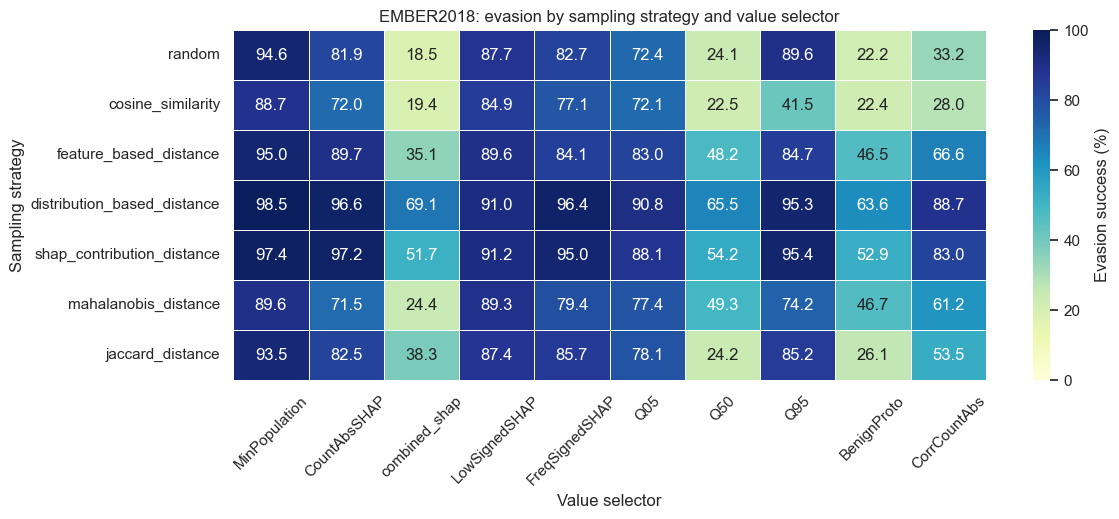

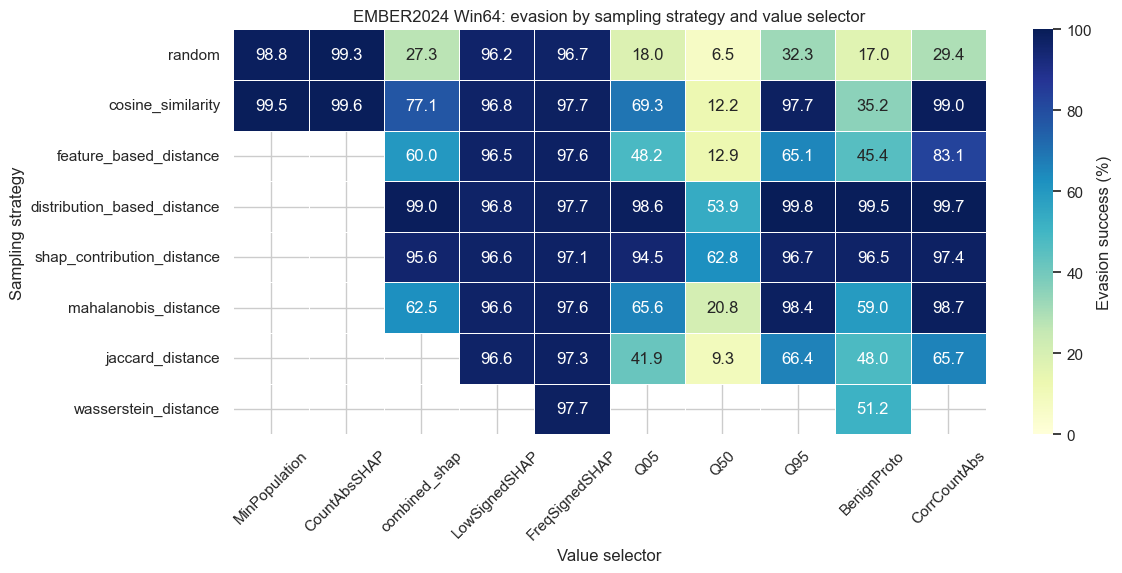

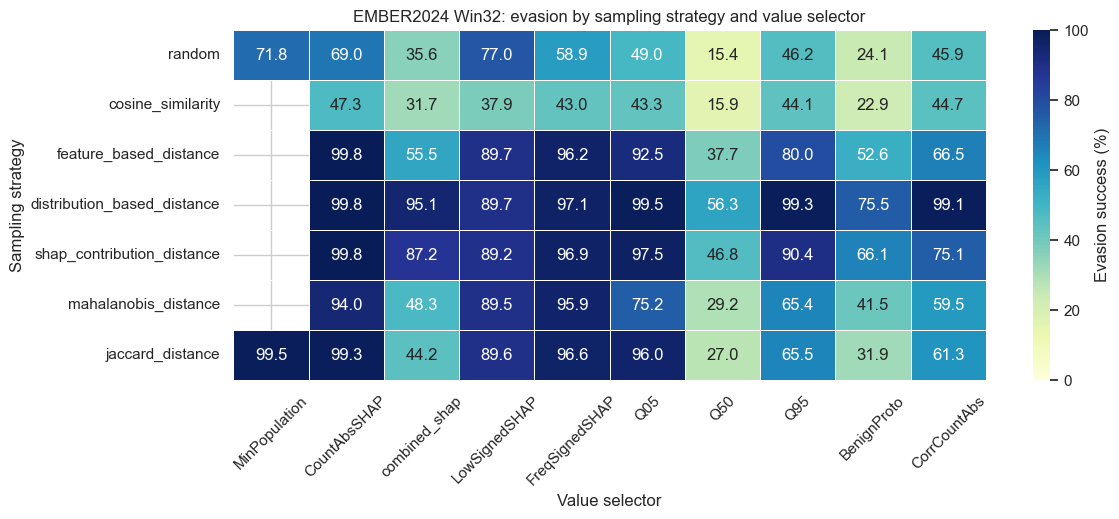

In [137]:
for dataset_label in DATASET_ROOTS.keys():
    d = plot_df[plot_df["dataset_label"] == dataset_label].copy()
    if d.empty:
        print("No graph data for", dataset_label)
        continue

    pivot = d.pivot_table(
        index="sampling_strategy",
        columns="value_selector",
        values="evasion_percent",
        aggfunc="max",
        observed=True,
    ).reindex(index=SAMPLING_ORDER, columns=PLOT_VALUE_SELECTORS)
    pivot = pivot.rename(columns=SELECTOR_LABELS)
    pivot = pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if pivot.empty:
        print("No non-empty evasion pivot for", dataset_label)
        continue

    fig_width = max(12, 0.75 * pivot.shape[1])
    fig_height = max(4, 0.55 * pivot.shape[0] + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Evasion success (%)"},
        ax=ax,
    )
    ax.set_title(f"{dataset_label}: evasion by sampling strategy and value selector")
    ax.set_xlabel("Value selector")
    ax.set_ylabel("Sampling strategy")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

### Sampling Gain/Loss Relative to Random

These heatmaps subtract the random-sampling evasion for the same dataset and selector. Positive values mean that sampling strategy improved evasion over random; negative values mean it hurt evasion.

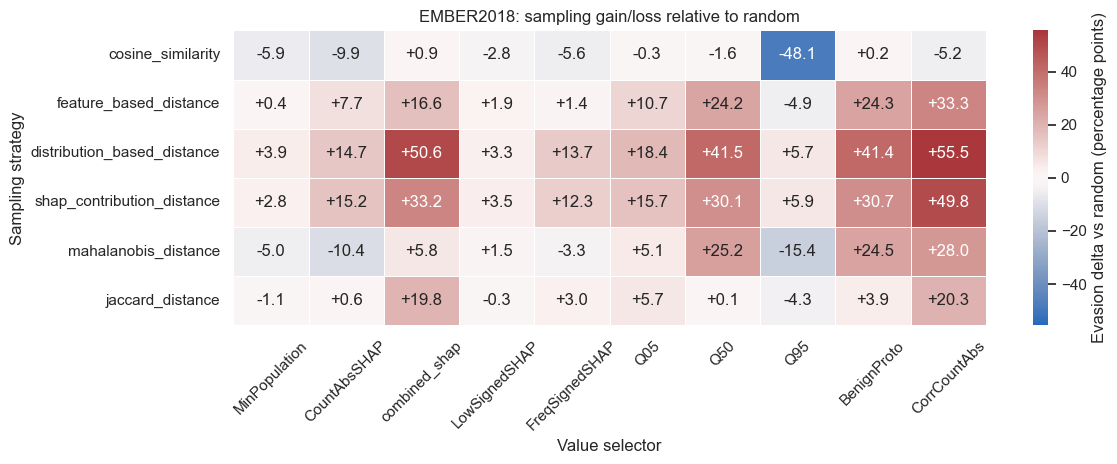

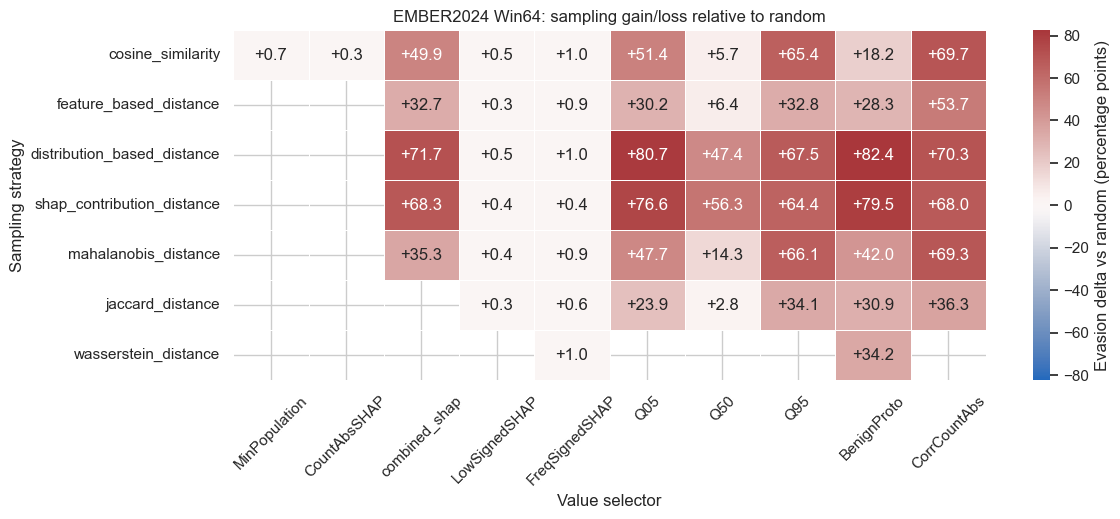

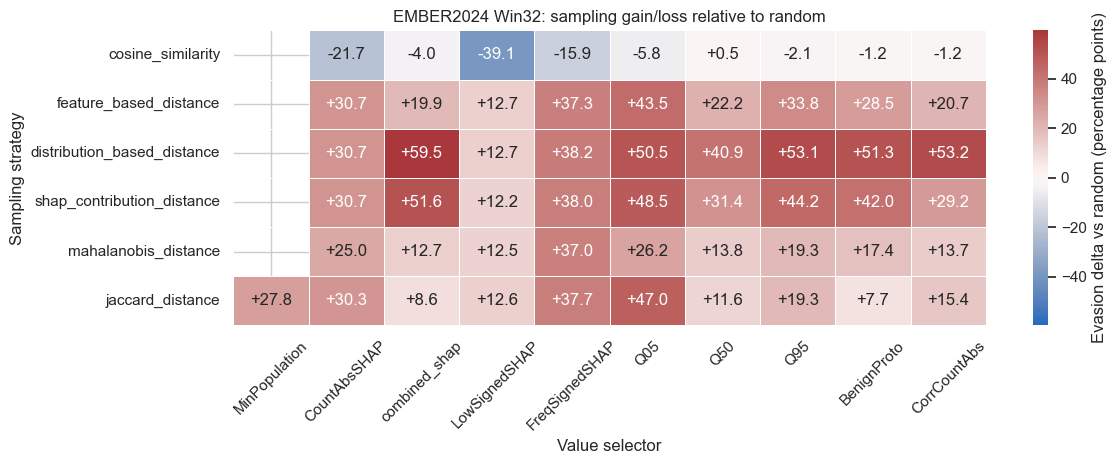

In [138]:
for dataset_label in DATASET_ROOTS.keys():
    d = plot_df[plot_df["dataset_label"] == dataset_label].copy()
    if d.empty:
        continue

    pivot = d.pivot_table(
        index="sampling_strategy",
        columns="value_selector",
        values="evasion_percent",
        aggfunc="max",
        observed=True,
    ).reindex(index=SAMPLING_ORDER, columns=PLOT_VALUE_SELECTORS)

    if "random" not in pivot.index or pivot.loc["random"].isna().all():
        print(f"Skipping {dataset_label}: no random baseline available for delta plot")
        continue

    delta = pivot.subtract(pivot.loc["random"], axis=1)
    delta = delta.drop(index="random", errors="ignore")
    delta = delta.rename(columns=SELECTOR_LABELS)
    delta = delta.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if delta.empty:
        print(f"Skipping {dataset_label}: no non-random deltas available")
        continue

    limit = np.nanmax(np.abs(delta.to_numpy()))
    limit = max(float(limit), 1.0)
    fig_width = max(12, 0.75 * delta.shape[1])
    fig_height = max(4, 0.55 * delta.shape[0] + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        delta,
        annot=True,
        fmt="+.1f",
        cmap="vlag",
        center=0,
        vmin=-limit,
        vmax=limit,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Evasion delta vs random (percentage points)"},
        ax=ax,
    )
    ax.set_title(f"{dataset_label}: sampling gain/loss relative to random")
    ax.set_xlabel("Value selector")
    ax.set_ylabel("Sampling strategy")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

### Best New Selector Per Dataset and Sampling Strategy

This ignores `min_population_new` and `argmin_Nv_sum_abs_shap`, then shows the best-performing new value selector for each dataset/sampling pair.

,dataset_label,sampling_strategy,selector_label,evasion_percent,clean_accuracy_percent,clean_accuracy_drop,num_poisoned,num_watermark_features
64,EMBER2018,random,Q95,89.569,87.188,12.812,600,17
6,EMBER2018,cosine_similarity,LowSignedSHAP,84.880,85.453,14.547,600,17
28,EMBER2018,feature_based_distance,LowSignedSHAP,89.573,84.927,15.073,600,17
16,EMBER2018,distribution_based_distance,FreqSignedSHAP,96.382,86.076,13.924,600,17
76,EMBER2018,shap_contribution_distance,Q95,95.448,84.026,15.974,600,17
50,EMBER2018,mahalanobis_distance,LowSignedSHAP,89.259,84.692,15.308,600,17
39,EMBER2018,jaccard_distance,LowSignedSHAP,87.401,82.617,17.383,600,17
203,EMBER2024 Win32,random,LowSignedSHAP,76.991,97.229,2.771,10405,19
150,EMBER2024 Win32,cosine_similarity,CorrCountAbs,44.692,97.401,2.599,10405,19
172,EMBER2024 Win32,feature_based_distance,FreqSignedSHAP,96.244,97.726,2.274,10405,19


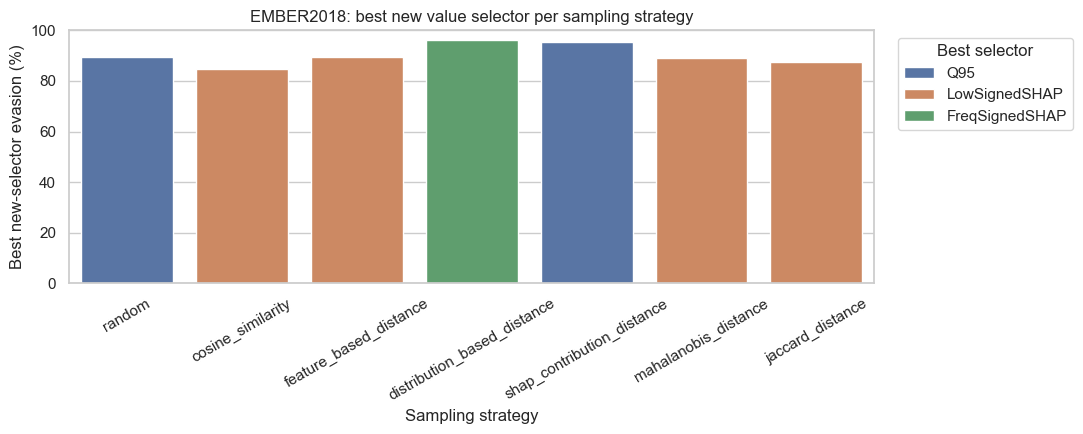

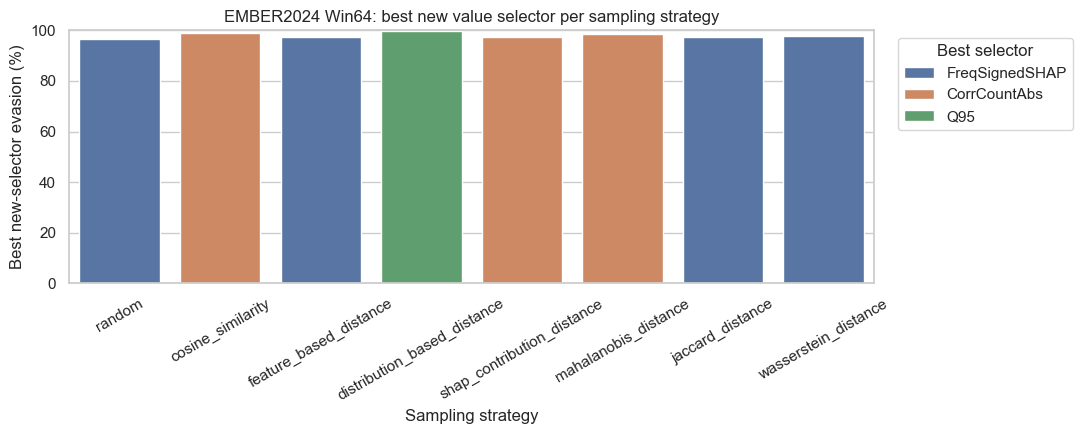

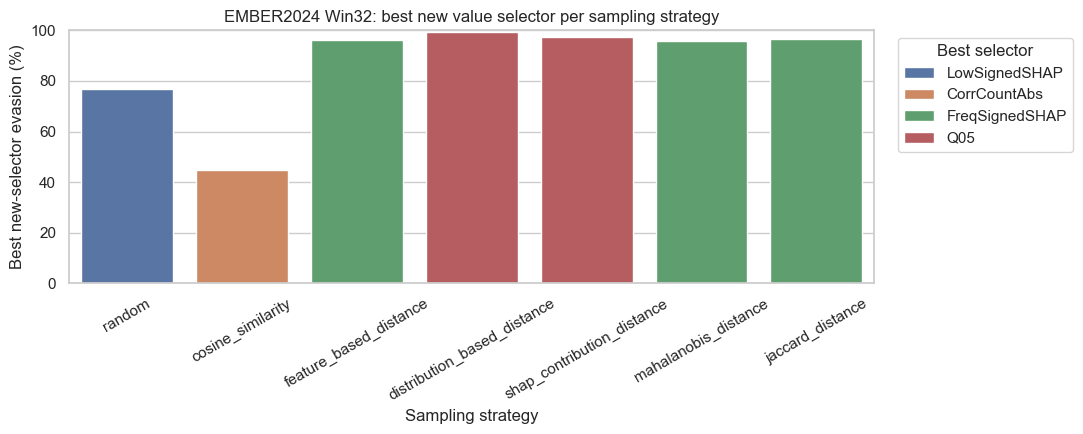

In [139]:
new_only = plot_df[plot_df["is_new_selector"]].copy()

best_new = (
    new_only
    .sort_values("evasion_percent", ascending=False)
    .groupby(["dataset_label", "sampling_strategy"], observed=True, as_index=False)
    .head(1)
    .sort_values(["dataset_label", "sampling_strategy"])
)

display(
    best_new[[
        "dataset_label",
        "sampling_strategy",
        "selector_label",
        "evasion_percent",
        "clean_accuracy_percent",
        "clean_accuracy_drop",
        "num_poisoned",
        "num_watermark_features",
    ]].round(3)
)

for dataset_label in DATASET_ROOTS.keys():
    d = best_new[best_new["dataset_label"] == dataset_label].copy()
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(11, 4.5))
    sns.barplot(
        data=d,
        x="sampling_strategy",
        y="evasion_percent",
        hue="selector_label",
        order=[s for s in SAMPLING_ORDER if s in set(d["sampling_strategy"].astype(str))],
        dodge=False,
        ax=ax,
    )
    ax.set_ylim(0, 100)
    ax.set_title(f"{dataset_label}: best new value selector per sampling strategy")
    ax.set_xlabel("Sampling strategy")
    ax.set_ylabel("Best new-selector evasion (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Best selector", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Clean Accuracy vs Evasion

This scatter plot checks whether high evasion comes with a clean-accuracy cost. Marker shape is the sampling strategy; color is the selector.

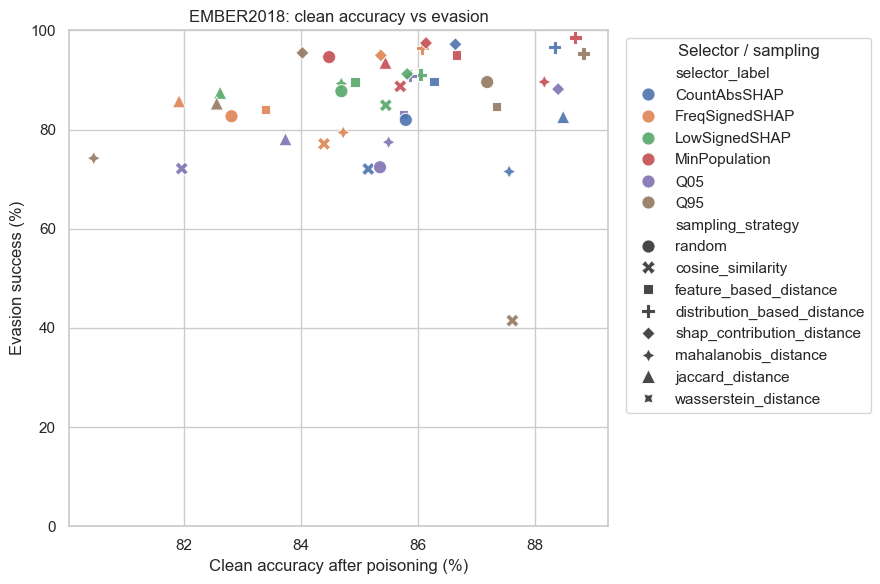

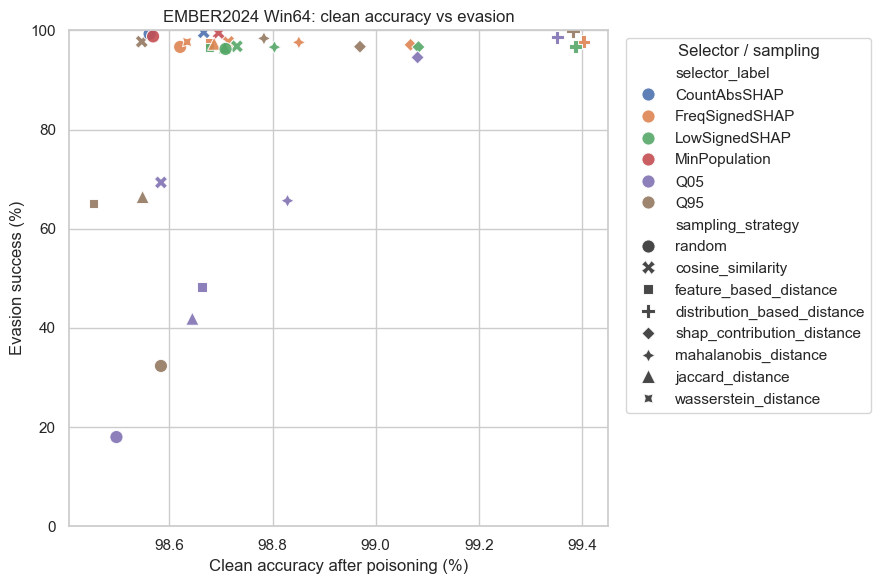

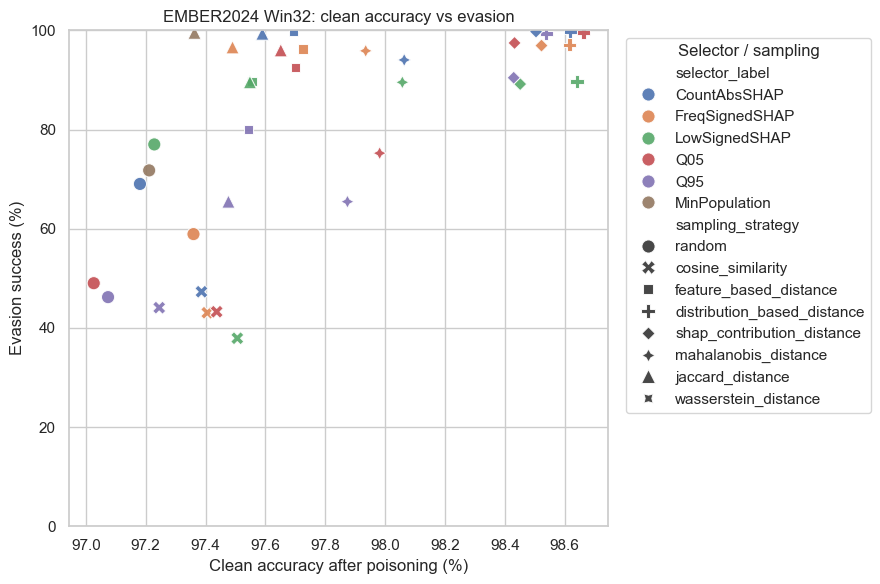

In [140]:
scatter_selectors = [
    "min_population_new",
    "argmin_Nv_sum_abs_shap",
    "frequency_bounded_signed_shap",
    "freq_0p1_1p",
    "freq_0p1_5p",
    "freq_0p5_5p",
    "freq_1p_10p",
    "quantile_05",
    "quantile_95",
    "low_shap_signed",
]

scatter_df = plot_df[plot_df["value_selector"].astype(str).isin(scatter_selectors)].copy()
scatter_df["selector_label"] = scatter_df["value_selector"].astype(str).map(SELECTOR_LABELS)

for dataset_label in DATASET_ROOTS.keys():
    d = scatter_df[scatter_df["dataset_label"] == dataset_label].copy()
    if d.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.scatterplot(
        data=d,
        x="clean_accuracy_percent",
        y="evasion_percent",
        hue="selector_label",
        style="sampling_strategy",
        s=90,
        alpha=0.9,
        ax=ax,
    )
    ax.set_title(f"{dataset_label}: clean accuracy vs evasion")
    ax.set_xlabel("Clean accuracy after poisoning (%)")
    ax.set_ylabel("Evasion success (%)")
    ax.set_ylim(0, 100)
    ax.legend(title="Selector / sampling", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Selector and Sampling Rankings

In [141]:
selector_summary = (
    main_results
    .groupby(["dataset_label", "selector_pair"])
    .agg(
        runs=("summary_path", "size"),
        best_evasion=("evasion_percent", "max"),
        mean_evasion=("evasion_percent", "mean"),
        best_clean_accuracy=("clean_accuracy_percent", "max"),
        mean_clean_accuracy=("clean_accuracy_percent", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_label", "best_evasion"], ascending=[True, False])
)
display(selector_summary.round(3))

sampling_summary = (
    main_results
    .groupby(["dataset_label", "sampling_strategy"])
    .agg(
        runs=("summary_path", "size"),
        best_evasion=("evasion_percent", "max"),
        mean_evasion=("evasion_percent", "mean"),
        best_clean_accuracy=("clean_accuracy_percent", "max"),
        mean_clean_accuracy=("clean_accuracy_percent", "mean"),
    )
    .reset_index()
    .sort_values(["dataset_label", "best_evasion"], ascending=[True, False])
)
display(sampling_summary.round(3))

,dataset_label,selector_pair,runs,best_evasion,mean_evasion,best_clean_accuracy,mean_clean_accuracy
7,EMBER2018,shap_largest_abs + min_population_new,7,98.526,93.910,88.695,86.470
1,EMBER2018,shap_largest_abs + argmin_Nv_sum_abs_shap,7,97.181,84.492,88.489,86.895
4,EMBER2018,shap_largest_abs + frequency_bounded,6,96.769,81.763,88.019,85.111
5,EMBER2018,shap_largest_abs + frequency_bounded_signed_shap,7,96.382,85.753,86.076,84.098
10,EMBER2018,shap_largest_abs + quantile_95,7,95.448,80.848,88.835,85.433
6,EMBER2018,shap_largest_abs + low_shap_signed,7,91.201,88.724,86.045,84.892
8,EMBER2018,shap_largest_abs + quantile_05,7,90.810,80.285,88.402,85.225
3,EMBER2018,shap_largest_abs + corr_count_abs_shap,7,88.691,59.174,87.666,84.910
11,EMBER2018,shap_largest_abs + signed_shap_min,1,87.716,87.716,84.693,84.693
0,EMBER2018,combined_shap + combined_shap,7,69.127,36.642,87.889,86.098


,dataset_label,sampling_strategy,runs,best_evasion,mean_evasion,best_clean_accuracy,mean_clean_accuracy
1,EMBER2018,distribution_based_distance,11,98.526,86.580,88.835,86.488
6,EMBER2018,shap_contribution_distance,11,97.443,81.604,89.219,86.810
2,EMBER2018,feature_based_distance,11,95.034,73.126,87.653,85.793
5,EMBER2018,random,11,94.598,63.147,87.188,84.477
3,EMBER2018,jaccard_distance,11,93.467,66.605,88.489,84.019
4,EMBER2018,mahalanobis_distance,11,89.594,66.684,88.166,84.543
0,EMBER2018,cosine_similarity,11,88.710,54.568,87.619,84.321
8,EMBER2024 Win32,distribution_based_distance,10,99.868,91.116,98.662,98.573
9,EMBER2024 Win32,feature_based_distance,10,99.798,77.021,97.726,97.654
13,EMBER2024 Win32,shap_contribution_distance,10,99.750,84.782,98.522,98.427


## Missing Experiment Grid

This compares discovered summaries against the editable grid at the top of the notebook. It answers: which dataset x sampling strategy x feature selector x value selector x target-feature combinations are still missing?

In [142]:
expected_rows = []
for dataset_label, sampling_strategy, target_features, selector_pair in product(
    DATASET_ROOTS.keys(),
    EXPECTED_SAMPLING_STRATEGIES,
    EXPECTED_TARGET_FEATURES,
    EXPECTED_SELECTOR_PAIRS,
):
    feature_selector, value_selector = selector_pair
    expected_rows.append({
        "dataset_label": dataset_label,
        "sampling_strategy": sampling_strategy,
        "feature_selector": feature_selector,
        "value_selector": value_selector,
        "target_features": target_features,
        "selector_pair": feature_selector + " + " + value_selector,
    })

expected_df = pd.DataFrame(expected_rows)
observed_keys = (
    results_df[["dataset_label", "sampling_strategy", "feature_selector", "value_selector", "target_features"]]
    .drop_duplicates()
    .assign(found=True)
)

missing_df = (
    expected_df
    .merge(
        observed_keys,
        on=["dataset_label", "sampling_strategy", "feature_selector", "value_selector", "target_features"],
        how="left",
    )
)
missing_df = missing_df[missing_df["found"].isna()].drop(columns=["found"]).copy()

print("Expected combinations:", len(expected_df))
print("Observed expected combinations:", len(expected_df) - len(missing_df))
print("Missing combinations:", len(missing_df))

missing_counts = (
    missing_df
    .groupby(["dataset_label", "sampling_strategy"])
    .size()
    .rename("missing_count")
    .reset_index()
    .pivot(index="dataset_label", columns="sampling_strategy", values="missing_count")
    .fillna(0)
    .astype(int)
)
display(missing_counts)

display(missing_df.sort_values(["dataset_label", "sampling_strategy", "selector_pair"]))

Expected combinations: 432
Observed expected combinations: 196
Missing combinations: 236


sampling_strategy,cosine_similarity,distribution_based_distance,feature_based_distance,jaccard_distance,mahalanobis_distance,random,shap_contribution_distance,wasserstein_distance
dataset_label,,,,,,,,
EMBER2018,8,8,8,8,8,8,8,18
EMBER2024 Win32,9,9,9,8,9,8,9,18
EMBER2024 Win64,8,10,10,11,10,8,10,16


,dataset_label,sampling_strategy,feature_selector,value_selector,target_features,selector_pair
23,EMBER2018,cosine_similarity,shap_largest_abs,freq_0p1_1p,problem_space_conservative,shap_largest_abs + freq_0p1_1p
24,EMBER2018,cosine_similarity,shap_largest_abs,freq_0p1_5p,problem_space_conservative,shap_largest_abs + freq_0p1_5p
25,EMBER2018,cosine_similarity,shap_largest_abs,freq_0p5_5p,problem_space_conservative,shap_largest_abs + freq_0p5_5p
26,EMBER2018,cosine_similarity,shap_largest_abs,freq_1p_10p,problem_space_conservative,shap_largest_abs + freq_1p_10p
28,EMBER2018,cosine_similarity,shap_largest_abs,quantile_10,problem_space_conservative,shap_largest_abs + quantile_10
29,EMBER2018,cosine_similarity,shap_largest_abs,quantile_25,problem_space_conservative,shap_largest_abs + quantile_25
31,EMBER2018,cosine_similarity,shap_largest_abs,quantile_75,problem_space_conservative,shap_largest_abs + quantile_75
32,EMBER2018,cosine_similarity,shap_largest_abs,quantile_90,problem_space_conservative,shap_largest_abs + quantile_90
59,EMBER2018,distribution_based_distance,shap_largest_abs,freq_0p1_1p,problem_space_conservative,shap_largest_abs + freq_0p1_1p
60,EMBER2018,distribution_based_distance,shap_largest_abs,freq_0p1_5p,problem_space_conservative,shap_largest_abs + freq_0p1_5p


## Wasserstein-Specific Missing Runs

Since Wasserstein was the strategy you explicitly mentioned, this cell isolates only the missing Wasserstein rows.

In [143]:
wasserstein_missing = missing_df[missing_df["sampling_strategy"] == "wasserstein_distance"].copy()
print("Missing wasserstein combinations:", len(wasserstein_missing))
display(wasserstein_missing.sort_values(["dataset_label", "selector_pair"]))

wasserstein_observed = main_results[main_results["sampling_strategy"] == "wasserstein_distance"].copy()
print("Observed wasserstein conservative summaries:", len(wasserstein_observed))
display(
    wasserstein_observed[cols]
    .sort_values(["dataset_label", "evasion_percent"], ascending=[True, False])
    .round(3)
)

Missing wasserstein combinations: 52


,dataset_label,sampling_strategy,feature_selector,value_selector,target_features,selector_pair
126,EMBER2018,wasserstein_distance,combined_shap,combined_shap,problem_space_conservative,combined_shap + combined_shap
128,EMBER2018,wasserstein_distance,shap_largest_abs,argmin_Nv_sum_abs_shap,problem_space_conservative,shap_largest_abs + argmin_Nv_sum_abs_shap
142,EMBER2018,wasserstein_distance,shap_largest_abs,benign_prototype,problem_space_conservative,shap_largest_abs + benign_prototype
143,EMBER2018,wasserstein_distance,shap_largest_abs,corr_count_abs_shap,problem_space_conservative,shap_largest_abs + corr_count_abs_shap
131,EMBER2018,wasserstein_distance,shap_largest_abs,freq_0p1_1p,problem_space_conservative,shap_largest_abs + freq_0p1_1p
132,EMBER2018,wasserstein_distance,shap_largest_abs,freq_0p1_5p,problem_space_conservative,shap_largest_abs + freq_0p1_5p
133,EMBER2018,wasserstein_distance,shap_largest_abs,freq_0p5_5p,problem_space_conservative,shap_largest_abs + freq_0p5_5p
134,EMBER2018,wasserstein_distance,shap_largest_abs,freq_1p_10p,problem_space_conservative,shap_largest_abs + freq_1p_10p
130,EMBER2018,wasserstein_distance,shap_largest_abs,frequency_bounded_signed_shap,problem_space_conservative,shap_largest_abs + frequency_bounded_signed_shap
129,EMBER2018,wasserstein_distance,shap_largest_abs,low_shap_signed,problem_space_conservative,shap_largest_abs + low_shap_signed


Observed wasserstein conservative summaries: 2


,dataset_label,sampling_strategy,selector_pair,evasion_percent,clean_accuracy_percent,clean_accuracy_drop,watermarked_malware_accuracy_percent,num_poisoned,num_watermark_features
146,EMBER2024 Win64,wasserstein_distance,shap_largest_abs + frequency_bounded_signed_shap,97.656,98.634,1.366,0.027,10400,19
145,EMBER2024 Win64,wasserstein_distance,shap_largest_abs + benign_prototype,51.208,98.643,1.357,48.247,10400,19


## Optional CSV Export

Set `SAVE_TABLES = True` to export the normalized result and missing-grid tables under `results/tables/`.

In [144]:
SAVE_TABLES = False

if SAVE_TABLES:
    out_dir = RESULTS_ROOT / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    results_path = out_dir / "sampling_value_selector_results.csv"
    missing_path = out_dir / "sampling_value_selector_missing_grid.csv"
    main_results.to_csv(results_path, index=False)
    missing_df.to_csv(missing_path, index=False)
    print("Saved:", results_path)
    print("Saved:", missing_path)
else:
    print("SAVE_TABLES is False; no files written.")

SAVE_TABLES is False; no files written.
